# 03 / 인사이트 발굴 - AI4I 2020

**목표:** 각 고장모드의 발생 조건을 데이터에서 직접 발견한다.

어떤 구조(AND/양방향/등급별)로, 어떤 임계에서 고장을 일으키는지 모두 데이터로만 찾는다.

**발견 도구:**
- 결정트리: 어떤 변수 + 어떤 구조(트리 경로 = AND 관계)인지 발견.
- Youden's J (ROC): 찾은 변수의 정밀 임계.
- Mann-Whitney U + 효과크기: 인사이트가 통계적으로 유의한지 확인.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import roc_curve, auc, roc_auc_score
plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

_here = Path.cwd()
ROOT = next((p for p in [_here, *_here.parents] if (p / 'src').is_dir()), _here)
sys.path.insert(0, str(ROOT))
from src.config import FEATURES_CSV, FIGDIR
from src.physics import COL_OMEGA, COL_POWER, COL_DT, COL_STRAIN

FIGDIR.mkdir(parents=True, exist_ok=True)
feat = pd.read_csv(FEATURES_CSV, encoding='utf-8-sig')

raw = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]',
       'Torque [Nm]', 'Tool wear [min]']
X = feat[raw + [COL_OMEGA, COL_POWER, COL_DT, COL_STRAIN]].copy()
X['Type_ord'] = feat['Type'].map({'L': 0, 'M': 1, 'H': 2})
print('후보 피처:', list(X.columns))
print('shape:', feat.shape)

후보 피처: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Angular velocity [rad/s]', 'Mechanical power [W]', 'Temp difference [K]', 'Overstrain [min*Nm]', 'Type_ord']
shape: (10000, 18)


## 0. 함수 정의

- `discover_tree`: 한 고장모드에 결정트리를 학습해 (a) 어떤 변수를 쓰는지(중요도)
  (b) 어떤 구조/임계인지 확인.
- `youden`: ROC에서 Youden's J 최대 임계 + AUC.
- `mwu_effect`: Mann-Whitney U + 효과크기(rank-biserial = Cliff's delta).
- `reconstruct`: **발견한 조건**이 실제 라벨을 얼마나 재현하는지(교차표/일치율).

참고: 고장이 드물어 일치율만 보면 오해한다. 전부 '정상'으로 찍어도 99% 이상 나온다.
그래서 `reconstruct`는 그 '전부 정상' 기준선을 함께 출력한다. 기준선을 못 넘는 규칙도
있으므로(TWF), 일치율 대신 교차표의 오탐/미탐과 효과크기로 판단한다.

In [2]:
def discover_tree(mode_col, max_depth):
    y = feat[mode_col]
    clf = DecisionTreeClassifier(max_depth=max_depth, class_weight='balanced',
                                 random_state=0).fit(X, y)
    imp = pd.Series(clf.feature_importances_, index=X.columns)
    imp = imp[imp > 0].sort_values(ascending=False)
    auc_v = roc_auc_score(y, clf.predict_proba(X)[:, 1])
    print(f'[{mode_col}] 트리가 고른 변수(중요도):')
    print(imp.round(3).to_string())
    print(f'트리 AUC={auc_v:.3f}   발견한 조건(트리 경로):')
    print(export_text(clf, feature_names=list(X.columns)))
    return clf

def youden(y_true, score):
    fpr, tpr, thr = roc_curve(y_true, score)
    J = tpr - fpr
    i = int(np.argmax(J))
    return thr[i], auc(fpr, tpr), J[i]

def mwu_effect(feat, mask_mode, col):
    x = feat.loc[mask_mode, col].values
    y = feat.loc[~mask_mode, col].values
    U, p = stats.mannwhitneyu(x, y, alternative='two-sided')
    A = U / (len(x) * len(y))
    rrb = 2 * A - 1
    return dict(n=len(x), p=p, rank_biserial=rrb, mean_mode=x.mean(), mean_rest=y.mean())

def reconstruct(pred_mask, label, name):
    match = (pred_mask == (label == 1)).mean()
    base = (label == 0).mean()   # 전부 '정상'으로 찍었을 때의 일치율 = 불균형 기준선
    verdict = '기준선 상회' if match > base else '기준선 미달'
    print(f'[{name}] 발견한 조건 재구성 일치율 {match*100:.2f}% '
          f'(전부 정상 기준선 {base*100:.2f}% -> {verdict})')
    print(pd.crosstab(pred_mask.rename('predicted'), label))
    return match

disc = {}
pvals = {}

## 1. PWF

트리에게 "PWF인가"만 주고 어떤 변수/구조인지 찾게 한다.

In [3]:
discover_tree('PWF', max_depth=2)

# 하한/상한을 각각 독립 탐색: 중심 아래/위로 나눠 한쪽씩 Youden
center = feat[COL_POWER].median()
low_side = feat[feat[COL_POWER] < center]
high_side = feat[feat[COL_POWER] >= center]
thr_lo, _, _ = youden(low_side['PWF'], -low_side[COL_POWER])
lo = -thr_lo
thr_hi, _, _ = youden(high_side['PWF'], high_side[COL_POWER])
hi = thr_hi
disc['PWF'] = f'P<{lo:.0f} or P>{hi:.0f}'
print(f'\n발견한 임계값(하한/상한 독립): 정상밴드 [{lo:.0f}, {hi:.0f}] W 밖이면 PWF')

mask = (feat[COL_POWER] < lo) | (feat[COL_POWER] > hi)
reconstruct(mask, feat['PWF'], 'PWF')
# 유의성은 '중심에서의 거리'로 검정(양방향을 단방향화). 거리는 라벨과 무관한 변환.
feat['P_dist'] = (feat[COL_POWER] - center).abs()
res = mwu_effect(feat, feat['PWF'] == 1, 'P_dist')
pvals['PWF'] = res['p']
print(f"검정(중심거리): p={res['p']:.2e}, rank-biserial={res['rank_biserial']:+.3f}")

[PWF] 트리가 고른 변수(중요도):
Mechanical power [W]    1.0
트리 AUC=1.000   발견한 조건(트리 경로):
|--- Mechanical power [W] <= 9001.23
|   |--- Mechanical power [W] <= 3496.14
|   |   |--- class: 1
|   |--- Mechanical power [W] >  3496.14
|   |   |--- class: 0
|--- Mechanical power [W] >  9001.23
|   |--- class: 1


발견한 임계값(하한/상한 독립): 정상밴드 [3477, 9004] W 밖이면 PWF
[PWF] 발견한 조건 재구성 일치율 99.98% (전부 정상 기준선 99.05% -> 기준선 상회)
PWF           0   1
predicted          
False      9905   2
True          0  93
검정(중심거리): p=2.45e-63, rank-biserial=+1.000


## 2. HDF

트리 경로가 곧 구조(AND/OR/단일)를 알려준다.
임계값은 각 변수 단독 Youden(주변 최적)으로 잡아 AND한다. 이는 결합 최적은 아니지만,
트리가 찾은 결합 분기(dT/각속도 두 변수를 연속으로 밟는 경로)와 일치하므로 타당하다.

[HDF] 트리가 고른 변수(중요도):
Temp difference [K]         0.872
Angular velocity [rad/s]    0.128
Type_ord                    0.000
트리 AUC=0.999   발견한 조건(트리 경로):
|--- Temp difference [K] <= 8.65
|   |--- Angular velocity [rad/s] <= 144.51
|   |   |--- class: 1
|   |--- Angular velocity [rad/s] >  144.51
|   |   |--- class: 0
|--- Temp difference [K] >  8.65
|   |--- Type_ord <= 0.50
|   |   |--- class: 0
|   |--- Type_ord >  0.50
|   |   |--- class: 0


발견 임계: dT<8.60K (AUC=0.965), N<1379rpm (AUC=0.937)
충분성 확인(단독으론 부족해야 AND):
  dT 조건만 만족 677건 중 HDF 103 (정밀도 0.15)
  N  조건만 만족 1333건 중 HDF 112 (정밀도 0.08)
  둘 다(AND)   101건 중 HDF 101 (정밀도 1.00)
  -> 각 조건은 필요하나 단독 불충분, 교집합이 곧 HDF => AND 구조 (데이터로 확인)
[HDF] 발견한 조건 재구성 일치율 99.86% (전부 정상 기준선 98.85% -> 기준선 상회)
HDF           0    1
predicted           
False      9885   14
True          0  101
검정(dT): p=2.97e-66, rank-biserial=-0.931


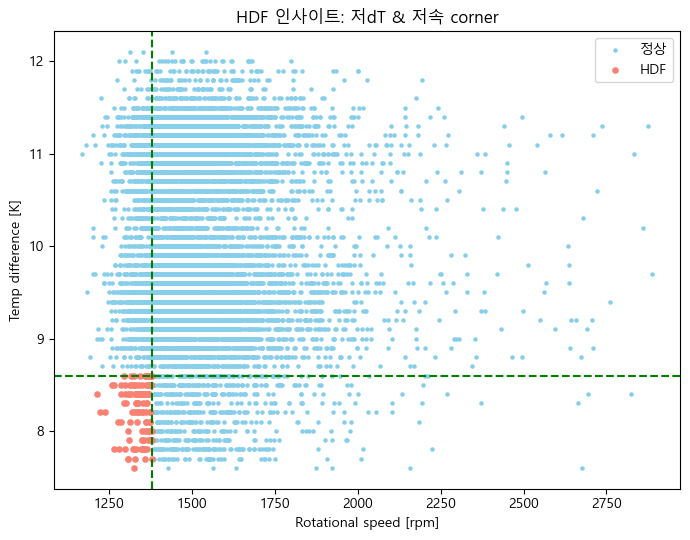

In [4]:
discover_tree('HDF', max_depth=2)

# 구조가 AND임을 필요/충분으로 재확인
thr_dt, auc_dt, _ = youden(feat['HDF'], -feat[COL_DT])
thr_n,  auc_n,  _ = youden(feat['HDF'], -feat['Rotational speed [rpm]'])
dt_c, n_c = -thr_dt, -thr_n
disc['HDF'] = f'dT<{dt_c:.2f} and N<{n_c:.0f}'
print(f'\n발견 임계: dT<{dt_c:.2f}K (AUC={auc_dt:.3f}), N<{n_c:.0f}rpm (AUC={auc_n:.3f})')

lowdt = feat[COL_DT] < dt_c
lown = feat['Rotational speed [rpm]'] < n_c
hdf = feat['HDF'] == 1
print('충분성 확인(단독으론 부족해야 AND):')
print(f'  dT 조건만 만족 {int(lowdt.sum())}건 중 HDF {int((lowdt&hdf).sum())} (정밀도 {hdf[lowdt].mean():.2f})')
print(f'  N  조건만 만족 {int(lown.sum())}건 중 HDF {int((lown&hdf).sum())} (정밀도 {hdf[lown].mean():.2f})')
print(f'  둘 다(AND)   {int((lowdt&lown).sum())}건 중 HDF {int((lowdt&lown&hdf).sum())} (정밀도 {hdf[lowdt&lown].mean():.2f})')
print('  -> 각 조건은 필요하나 단독 불충분, 교집합이 곧 HDF => AND 구조 (데이터로 확인)')

reconstruct(lowdt & lown, feat['HDF'], 'HDF')
res = mwu_effect(feat, hdf, COL_DT)
pvals['HDF'] = res['p']
print(f"검정(dT): p={res['p']:.2e}, rank-biserial={res['rank_biserial']:+.3f}")

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(feat.loc[~hdf, 'Rotational speed [rpm]'], feat.loc[~hdf, COL_DT], s=5, c='skyblue', label='정상')
ax.scatter(feat.loc[hdf, 'Rotational speed [rpm]'], feat.loc[hdf, COL_DT], s=14, c='salmon', label='HDF')
ax.axvline(n_c, color='g', ls='--')
ax.axhline(dt_c, color='g', ls='--')
ax.set_xlabel('Rotational speed [rpm]')
ax.set_ylabel('Temp difference [K]')
ax.set_title('HDF 인사이트: 저dT & 저속 corner')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '03_hdf_2d.png', dpi=120)
plt.show()

## 3. OSF

먼저 트리를 돌려 무엇을 쓰는지 본다. 트리는 지배적 규칙만 찾으므로, 소수인
등급(M/H) 차이는 놓칠 수 있다. 그때는 Phase 1 도메인 인사이트(등급=내성 차이)를
근거로 등급층화 Youden으로 등급별 임계값을 발견한다.

[OSF] 트리가 고른 변수(중요도):
Overstrain [min*Nm]     0.999
Tool wear [min]         0.000
Mechanical power [W]    0.000
Air temperature [K]     0.000
트리 AUC=0.999   발견한 조건(트리 경로):
|--- Overstrain [min*Nm] <= 10998.50
|   |--- Air temperature [K] <= 295.35
|   |   |--- class: 0
|   |--- Air temperature [K] >  295.35
|   |   |--- class: 0
|--- Overstrain [min*Nm] >  10998.50
|   |--- Tool wear [min] <= 166.50
|   |   |--- class: 0
|   |--- Tool wear [min] >  166.50
|   |   |--- Mechanical power [W] <= 6901.07
|   |   |   |--- class: 0
|   |   |--- Mechanical power [W] >  6901.07
|   |   |   |--- class: 1


등급별 Youden 임계값:
  L: OSF  87건, 임계   11003 (AUC=1.000)
  M: OSF   9건, 임계   12337 (AUC=1.000)
  H: OSF 2건 -> 표본 부족, 발견 불가
[OSF] 발견한 조건 재구성 일치율 99.98% (전부 정상 기준선 99.02% -> 기준선 상회)
OSF           0   1
predicted          
False      9902   2
True          0  96
검정(누적응력): p=5.09e-65, rank-biserial=+0.998
카이제곱 Type x OSF: chi2=34.2, p=3.70e-08 -> 등급과 OSF 연관


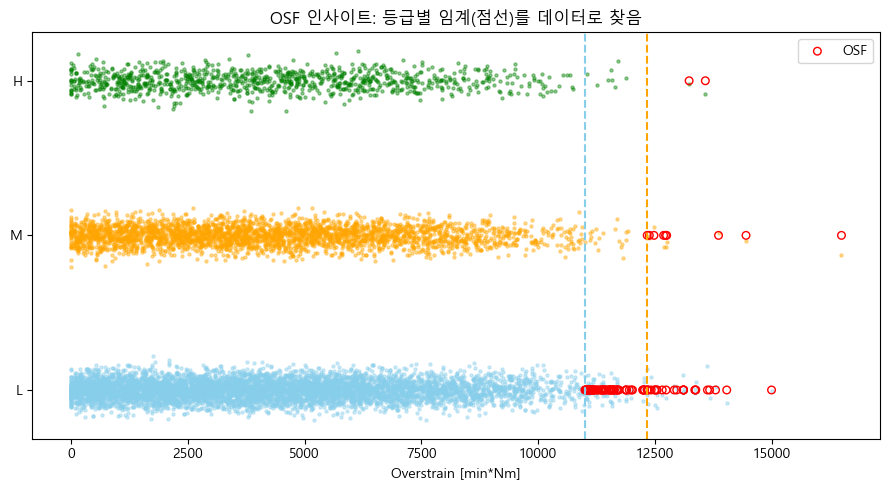

In [5]:
discover_tree('OSF', max_depth=3)
# 관찰(정직): 트리는 Overstrain 단일 임계 하나만 사용하고 Type_ord 중요도는 0 = 등급을 안 씀.
#   M/H OSF가 9+2건으로 소수라 트리가 등급 차이를 놓친 것.
#   -> 등급별 임계 상이는 트리가 아니라 아래 '등급층화 Youden'이 발견.
#   (트리의 한계 + 도메인 지식으로 층화하는 근거를 보여주는 지점)

osf = feat['OSF'] == 1
disc_osf = {}
print('\n등급별 Youden 임계값:')
for g in ['L', 'M', 'H']:
    sub = feat[feat['Type'] == g]
    n_osf = int((sub['OSF'] == 1).sum())
    if n_osf < 5:
        print(f'  {g}: OSF {n_osf}건 -> 표본 부족, 발견 불가')
        continue
    t, a, _ = youden(sub['OSF'], sub[COL_STRAIN])
    disc_osf[g] = t
    print(f'  {g}: OSF {n_osf:3d}건, 임계 {t:7.0f} (AUC={a:.3f})')
disc['OSF'] = 'L~{:.0f}/M~{:.0f} (H 표본부족)'.format(disc_osf.get('L', np.nan), disc_osf.get('M', np.nan))

# 발견한 등급별 임계로 재구성 (H는 M 임계로 근사)
def osf_pred(r):
    t = disc_osf.get(r['Type'], disc_osf.get('M'))
    return r[COL_STRAIN] > t
pred = feat.apply(osf_pred, axis=1)
reconstruct(pred, feat['OSF'], 'OSF')
res = mwu_effect(feat, osf, COL_STRAIN)
pvals['OSF'] = res['p']
print(f"검정(누적응력): p={res['p']:.2e}, rank-biserial={res['rank_biserial']:+.3f}")

# 등급-OSF 연관 카이제곱
chi2, p_osf, _, _ = stats.chi2_contingency(pd.crosstab(feat['Type'], feat['OSF']))
pvals['Type-OSF(chi2)'] = p_osf
print(f'카이제곱 Type x OSF: chi2={chi2:.1f}, p={p_osf:.2e} -> 등급과 OSF 연관')

fig, ax = plt.subplots(figsize=(9, 5))
colors = {'L': 'skyblue', 'M': 'orange', 'H': 'green'}
for g in ['L', 'M', 'H']:
    sub = feat[feat['Type'] == g]
    ax.scatter(sub[COL_STRAIN], np.random.normal(['L','M','H'].index(g), 0.06, len(sub)), s=5, c=colors[g], alpha=0.4)
    if g in disc_osf:
        ax.axvline(disc_osf[g], color=colors[g], ls='--')
op = feat[osf]
ax.scatter(op[COL_STRAIN], [['L','M','H'].index(g) for g in op['Type']], s=30, facecolors='none', edgecolors='red', label='OSF')
ax.set_yticks([0,1,2])
ax.set_yticklabels(['L','M','H'])
ax.set_xlabel('Overstrain [min*Nm]')
ax.set_title('OSF 인사이트: 등급별 임계(점선)를 데이터로 찾음')
ax.legend()
plt.tight_layout()
plt.savefig(FIGDIR / '03_osf_by_grade.png', dpi=120)
plt.show()

## 4. TWF

트리가 공구마모를 고르되 완벽히 못 가르는(랜덤) 것을 확인한다.

In [6]:
discover_tree('TWF', max_depth=2)
twf = feat['TWF'] == 1
t, a, _ = youden(feat['TWF'], feat['Tool wear [min]'])
disc['TWF'] = f'wear>{t:.0f}'
print(f'\n임계값: 마모>{t:.0f}min (AUC={a:.3f}) - AUC가 1이 아님에 주목')

hi = feat['Tool wear [min]'] > t
match = reconstruct(hi, feat['TWF'], 'TWF')
fp = int((hi & ~twf).sum())
print(f'마모>{t:.0f} 인 {int(hi.sum())}건 중 TWF는 {int((hi&twf).sum())}건뿐 '
      f'-> 마모는 필요조건이나 충분하지 않음(랜덤 발생). 완벽히 안 갈리는 게 정상.')
print(f'주의: 일치율 {match*100:.2f}%가 기준선보다 낮은 유일한 모드. 오탐 {fp}건 탓이다.')
print('  조건이 틀린 게 아니라 결정론적 재구성 자체가 불가능한 모드라서다.')
print('  -> 일치율은 불균형에서 오해를 부르는 지표. 교차표/효과크기로 판단.')
res = mwu_effect(feat, twf, 'Tool wear [min]')
pvals['TWF'] = res['p']
print(f"검정(마모): p={res['p']:.2e}, rank-biserial={res['rank_biserial']:+.3f}")

[TWF] 트리가 고른 변수(중요도):
Tool wear [min]        1.0
Air temperature [K]    0.0
트리 AUC=0.967   발견한 조건(트리 경로):
|--- Tool wear [min] <= 197.50
|   |--- Air temperature [K] <= 295.35
|   |   |--- class: 0
|   |--- Air temperature [K] >  295.35
|   |   |--- class: 0
|--- Tool wear [min] >  197.50
|   |--- Tool wear [min] <= 202.50
|   |   |--- class: 1
|   |--- Tool wear [min] >  202.50
|   |   |--- class: 1


임계값: 마모>198min (AUC=0.972) - AUC가 1이 아님에 주목
[TWF] 발견한 조건 재구성 일치율 91.96% (전부 정상 기준선 99.54% -> 기준선 미달)
TWF           0   1
predicted          
False      9151   1
True        803  45
마모>198 인 848건 중 TWF는 45건뿐 -> 마모는 필요조건이나 충분하지 않음(랜덤 발생). 완벽히 안 갈리는 게 정상.
주의: 일치율 91.96%가 기준선보다 낮은 유일한 모드. 오탐 803건 탓이다.
  조건이 틀린 게 아니라 결정론적 재구성 자체가 불가능한 모드라서다.
  -> 일치율은 불균형에서 오해를 부르는 지표. 교차표/효과크기로 판단.
검정(마모): p=1.93e-28, rank-biserial=+0.944


## 5. 다중검정 보정 (Bonferroni)

In [7]:
m = len(pvals)
alpha = 0.05
print(f'검정 수 m={m}, Bonferroni alpha/m={alpha/m:.2e}\n')
for name, p in sorted(pvals.items(), key=lambda kv: kv[1]):
    print(f'  {name:16} p={p:.2e}  {"유의" if p < alpha/m else "x"}')

검정 수 m=5, Bonferroni alpha/m=1.00e-02

  HDF              p=2.97e-66  유의
  OSF              p=5.09e-65  유의
  PWF              p=2.45e-63  유의
  TWF              p=1.93e-28  유의
  Type-OSF(chi2)   p=3.70e-08  유의


## 6. 실제 조건과 비교

Matzka 2020에서 제시한 조건과 데이터에서 발견한 조건과 대조한다.

In [8]:
published = {
    'PWF': 'P<3500 or P>9000',
    'HDF': 'dT<8.6 and N<1380',
    'OSF': 'L 11000 / M 12000 / H 13000',
    'TWF': 'wear 200~240 (random)',
}
tbl = pd.DataFrame({
    '모드': list(published.keys()),
    '데이터에서 발견한 조건': [disc.get(k, '-') for k in published],
    'Matzka 2020': [published[k] for k in published],
})
print(tbl.to_string(index=False))
print('\n=> 발견한 조건이 거의 일치.')

 모드             데이터에서 발견한 조건                 Matzka 2020
PWF         P<3477 or P>9004            P<3500 or P>9000
HDF       dT<8.60 and N<1379           dT<8.6 and N<1380
OSF L~11003/M~12337 (H 표본부족) L 11000 / M 12000 / H 13000
TWF                 wear>198       wear 200~240 (random)

=> 발견한 조건이 거의 일치.


## 결론 (Phase 3)

- 결정트리(변수/구조) + Youden(임계) + 검정(유의성)으로 각 고장모드의 조건을 데이터에서 발견.
- PWF=양방향(band), HDF=AND(dT & 속도), OSF=등급별 임계, TWF=부분 예측(랜덤).
- Matzka 2020 조건과 대조하니 발견값이 거의 정확히 일치 -> 발견 파이프라인이
  알려진 물리를 실제로 복원함을 증명(실데이터에선 정답이 없어 대조 자체가 불가능).
- 합성 데이터라 100%에 가깝게 복원됨. 실데이터면 통계적 연관(효과크기/AUC)으로
  평가. OSF의 H등급은 표본 2건으로 발견 불가 - 데이터 기반 발견의 실제 한계.
- 방법론 한계: 트리 AUC/재구성은 in-sample(발견용). 트리는 소수 상호작용(OSF 등급)을 놓칠 수
  있어 도메인 기반 층화로 보완함.
- Phase 4 대비: 후보 피처에 공선성 존재(omega=speed 상수배, power=torque*omega, dT=온도차).
  트리 계열 모델은 상관없으나 선형 모델(로지스틱)에선 처리 필요. 등급은 순서형 대신 one-hot 검토.